# Simulating smHA-KDM5B

In [1]:
rsnapsim_dir = r'C:\Users\wsraymon\Github\rSNAPsim'
rsnaped_dir = r'C:\Users\wsraymon\Github\rSNAPed'
gene_file = r'C:\Users\wsraymon\Downloads\pNZ266(pUB-24xGCN4-KDM5B-MS2).dna'

### importing rSNAPed

In [2]:
%%capture
import os; from os import listdir; from os.path import isfile, join
import re  
from skimage.io import imread
from skimage.exposure import rescale_intensity
import numpy as np 
from tqdm.notebook import tqdm
from timeit import default_timer as timer
import scipy
import pandas as pd
import shutil
import pathlib
import sys
import seaborn as sns
from skimage.measure import approximate_polygon
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

import os
homedir = os.getcwd()
os.chdir(homedir)
os.chdir(rsnapsim_dir)
import rsnapsim as rsnp
os.chdir(homedir)

import scipy.stats as stats
import matplotlib.pyplot as plt 

plt.style.use("dark_background")

# Defining directories
current_dir = pathlib.Path(rsnaped_dir).absolute()
sequences_dir = current_dir.joinpath('DataBases','gene_files')
video_dir = current_dir.joinpath('DataBases','videos_for_sim_cell')
masks_dir = current_dir.joinpath('DataBases','masks_for_sim_cell')

# Importing rSNAPed
sys.path.append(str(current_dir.joinpath('rsnaped')))
import rsnaped as rsp


from IPython.display import HTML
import matplotlib.pyplot as plt
import matplotlib.animation 
import numpy as np


In [3]:
# Pick a base cell to simulate from
cell_num = np.random.randint(0,7)
video = imread(video_dir.joinpath('cell_shape_'+str(cell_num)+'.tif'))
mask_image = imread(masks_dir.joinpath('mask_cell_shape_'+str(cell_num)+'.tif'))

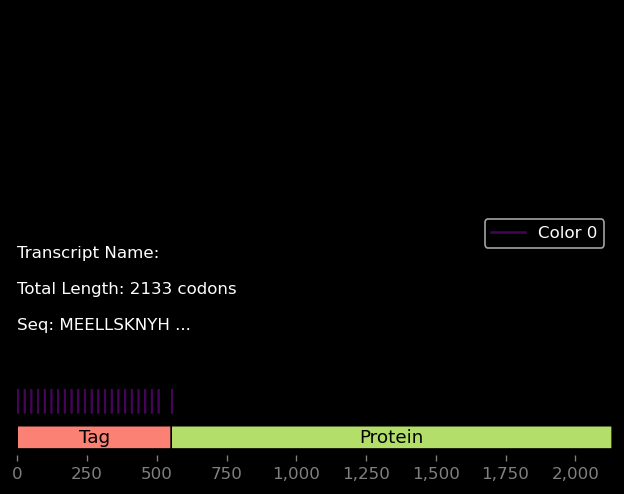

In [4]:
# Making the simulated cell class off of the kdm5b yaml
simulated_cell_KDM5B = rsp.SimCell2D(video, mask_image, '../kdm5b.yaml')

# overwrite mRNA 1, manually overwrite the kdm5b yaml with the correct CDS since by default it uses the first largest CDS.
_,_,tagged_CDSs,_ = rsnp.seqmanip.open_seq_file(str(gene_file), add_tag=False)
KDM5B = tagged_CDSs['-1'][0]
simulated_cell_KDM5B.mRNAs[0].mRNA_model = KDM5B #mRNA species 0's model = this new poi

KDM5B.visualize_mrna_strand()

In [5]:
n_spots = np.random.randint(25,50)
framerate = 5
t = np.array(range(0,1800+framerate,framerate)) # 0 to 1800s with 5s framerate

# randomizing diffusion rates a bit
simulated_cell_KDM5B.D = np.random.rand(n_spots)*3 + np.random.rand(n_spots)

video_array, simulated_intensity, spot_positions = simulated_cell_KDM5B.gen(n_spots, t, verbose=1, disk_buffer=False, buffer_size=25) #generate a video

Generating spot motion.....
Generating/loading intensity for mRNAs 0.....


Generating video frames: 100%|███████████████████████████████████████████████████████| 361/361 [00:19<00:00, 18.94it/s]


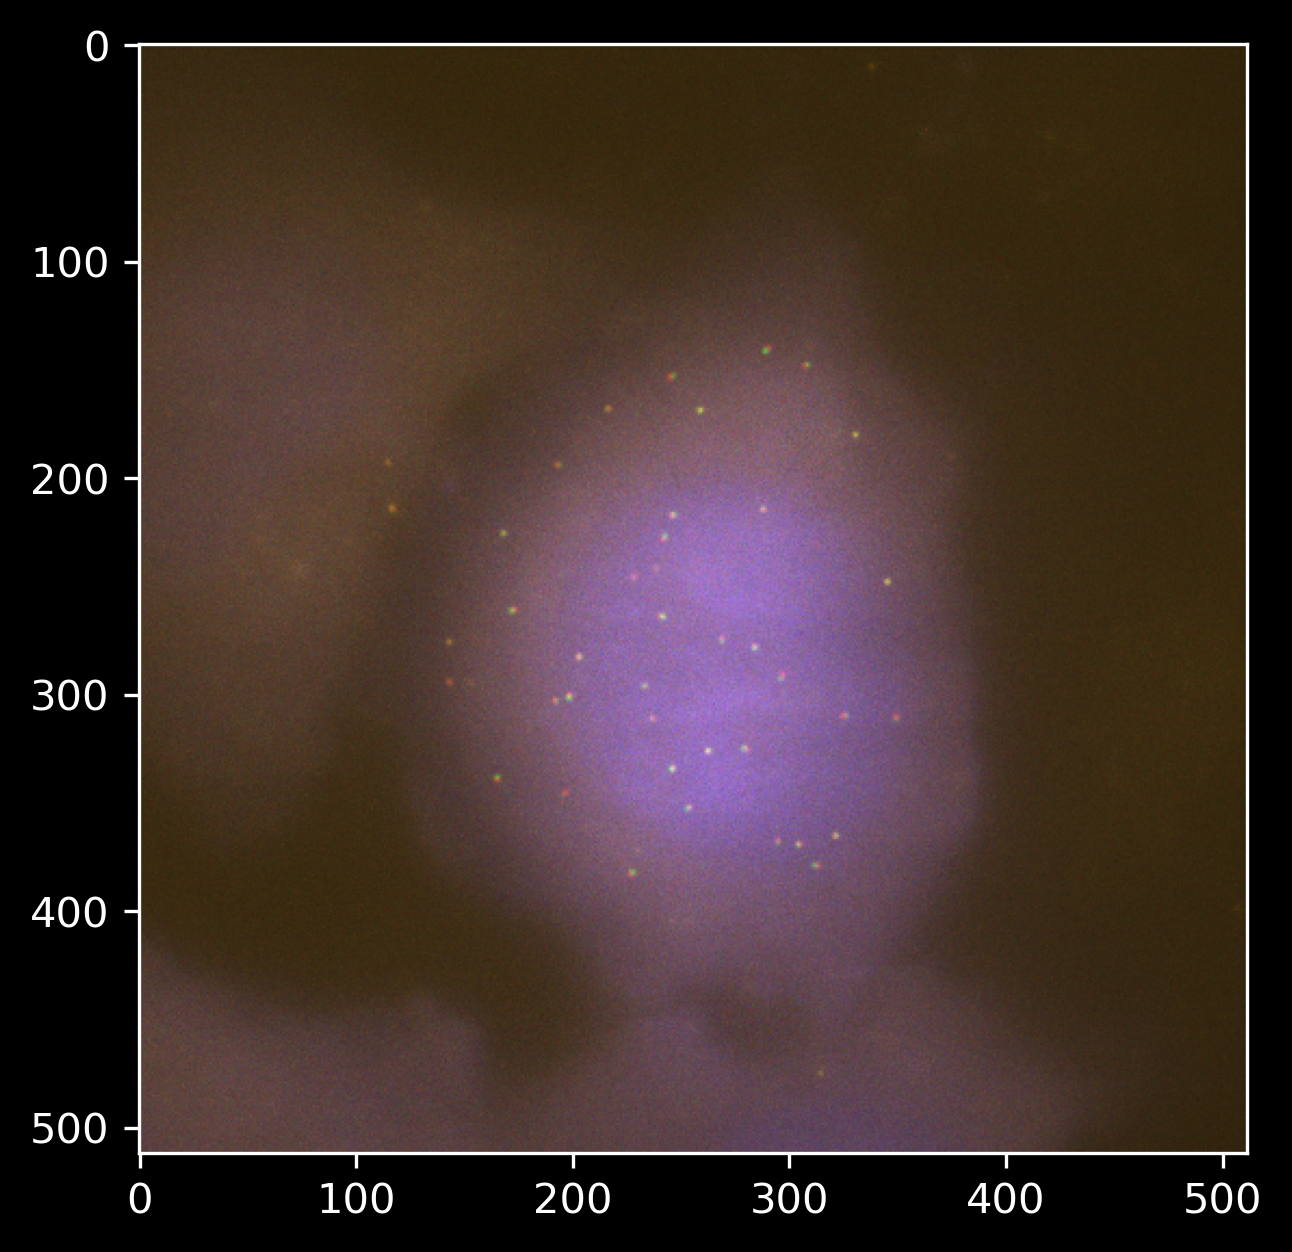

In [6]:
fig,ax = plt.subplots(1,1)
maxes = np.array([max(video_array[:,:,:,i].flatten()) for i in [0,1,2]])
maxes[2] = 14000
im = plt.imshow(video_array[0]/maxes)
def animate(i):
    im.set_array(video_array[i]/maxes)
    return [im]
ani = matplotlib.animation.FuncAnimation(fig, animate, frames=len(video_array))
HTML(ani.to_html5_video())


In [8]:
rsp.Util.write_video_to_tif(video_array, 'tSUN-KDM5B.tif', TimeIncrement=5)

In [ ]:
#I_recaptured, ss = rsp.Video_to_Intensity().convert_video_to_intensity(sample_vid, xy,)

In [9]:
import matplotlib.animation as animation
writer = animation.writers['ffmpeg'](fps=12, metadata=dict(artist='Me'), bitrate=1800)
ani.save('tSUN-kdm5b.mp4', writer=writer)


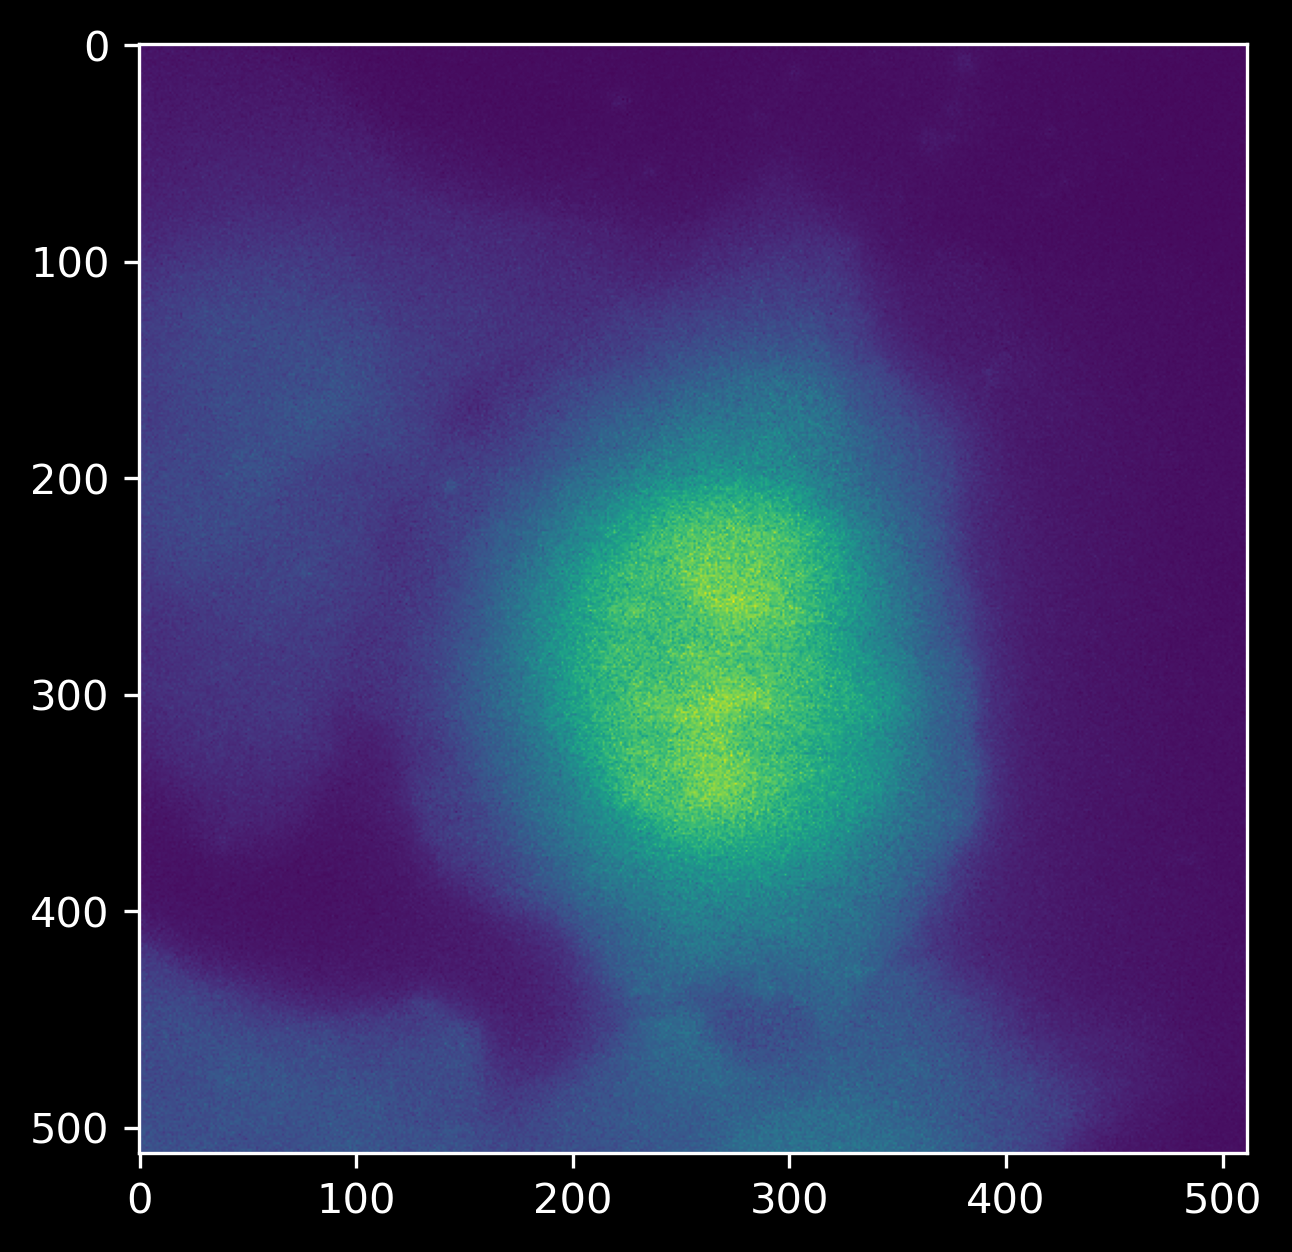

In [10]:
maxes = np.array([max(video_array[:,:,:,i].flatten()) for i in [0,1,2]])
im = plt.imshow(video_array[0,:,:,2]/maxes[2])

In [ ]:
np.quantile(video_array[:,:,:,-1],.995)

In [11]:
np.savez('simulated_intensity.npz', simulated_intensity)

In [12]:
np.savez('spot_positions.npz', spot_positions)